# Part1: IMPORT LIBRARIES AND DATASETS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import PIL
import pickle
from PIL import *
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
keyfacial_df = pd.read_csv(
    "/content/drive/My Drive/Emotion AI Dataset/data.csv"
)

keyfacial_df.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [4]:
# Obtain relavant information about the dataframe
keyfacial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [5]:
keyfacial_df.isnull().sum()

,0
left_eye_center_x,0
left_eye_center_y,0
right_eye_center_x,0
right_eye_center_y,0
left_eye_inner_corner_x,0
left_eye_inner_corner_y,0
left_eye_outer_corner_x,0
left_eye_outer_corner_y,0
right_eye_inner_corner_x,0
right_eye_inner_corner_y,0


In [6]:
keyfacial_df.duplicated().sum()

np.int64(0)

In [7]:
keyfacial_df.nunique()

,0
left_eye_center_x,2131
left_eye_center_y,2126
right_eye_center_x,2133
right_eye_center_y,2127
left_eye_inner_corner_x,2137
left_eye_inner_corner_y,2125
left_eye_outer_corner_x,2129
left_eye_outer_corner_y,2124
right_eye_inner_corner_x,2124
right_eye_inner_corner_y,2131


In [8]:
# Since values for the image are given as space separated string, separate the values using ' ' as separator.
# Then convert this into numpy array using np.fromstring and convert the obtained 1D array into 2D array of shape (96, 96)
keyfacial_df['Image'] = keyfacial_df['Image'].apply(lambda x: np.fromstring(x, dtype = int, sep = ' ').reshape(96, 96))

In [9]:
# Obtain the Shape of the image
keyfacial_df['Image'][1].shape

(96, 96)

In [10]:
print(keyfacial_df['left_eye_center_x'].min())
print(keyfacial_df['left_eye_center_x'].max())
print(keyfacial_df['left_eye_center_y'].mean())
print(keyfacial_df['left_eye_center_y'].median())

47.8357570574
78.013081792
36.8422741657263
36.91331906495


In [11]:
keyfacial_df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


# Part 2: PERFORM IMAGE VISUALIZATION

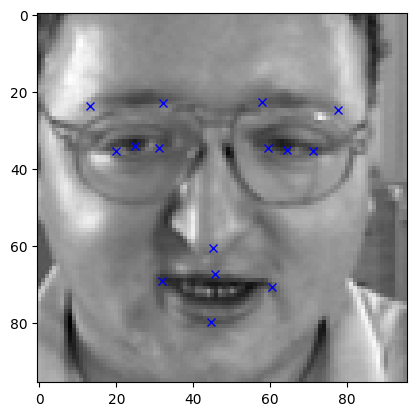

In [12]:
# Plot a random image from the dataset along with facial keypoints.

i = np.random.randint(1, len(keyfacial_df))
plt.imshow(keyfacial_df['Image'][i], cmap = 'gray')
for j in range(1, 31, 2):
        plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'bx')

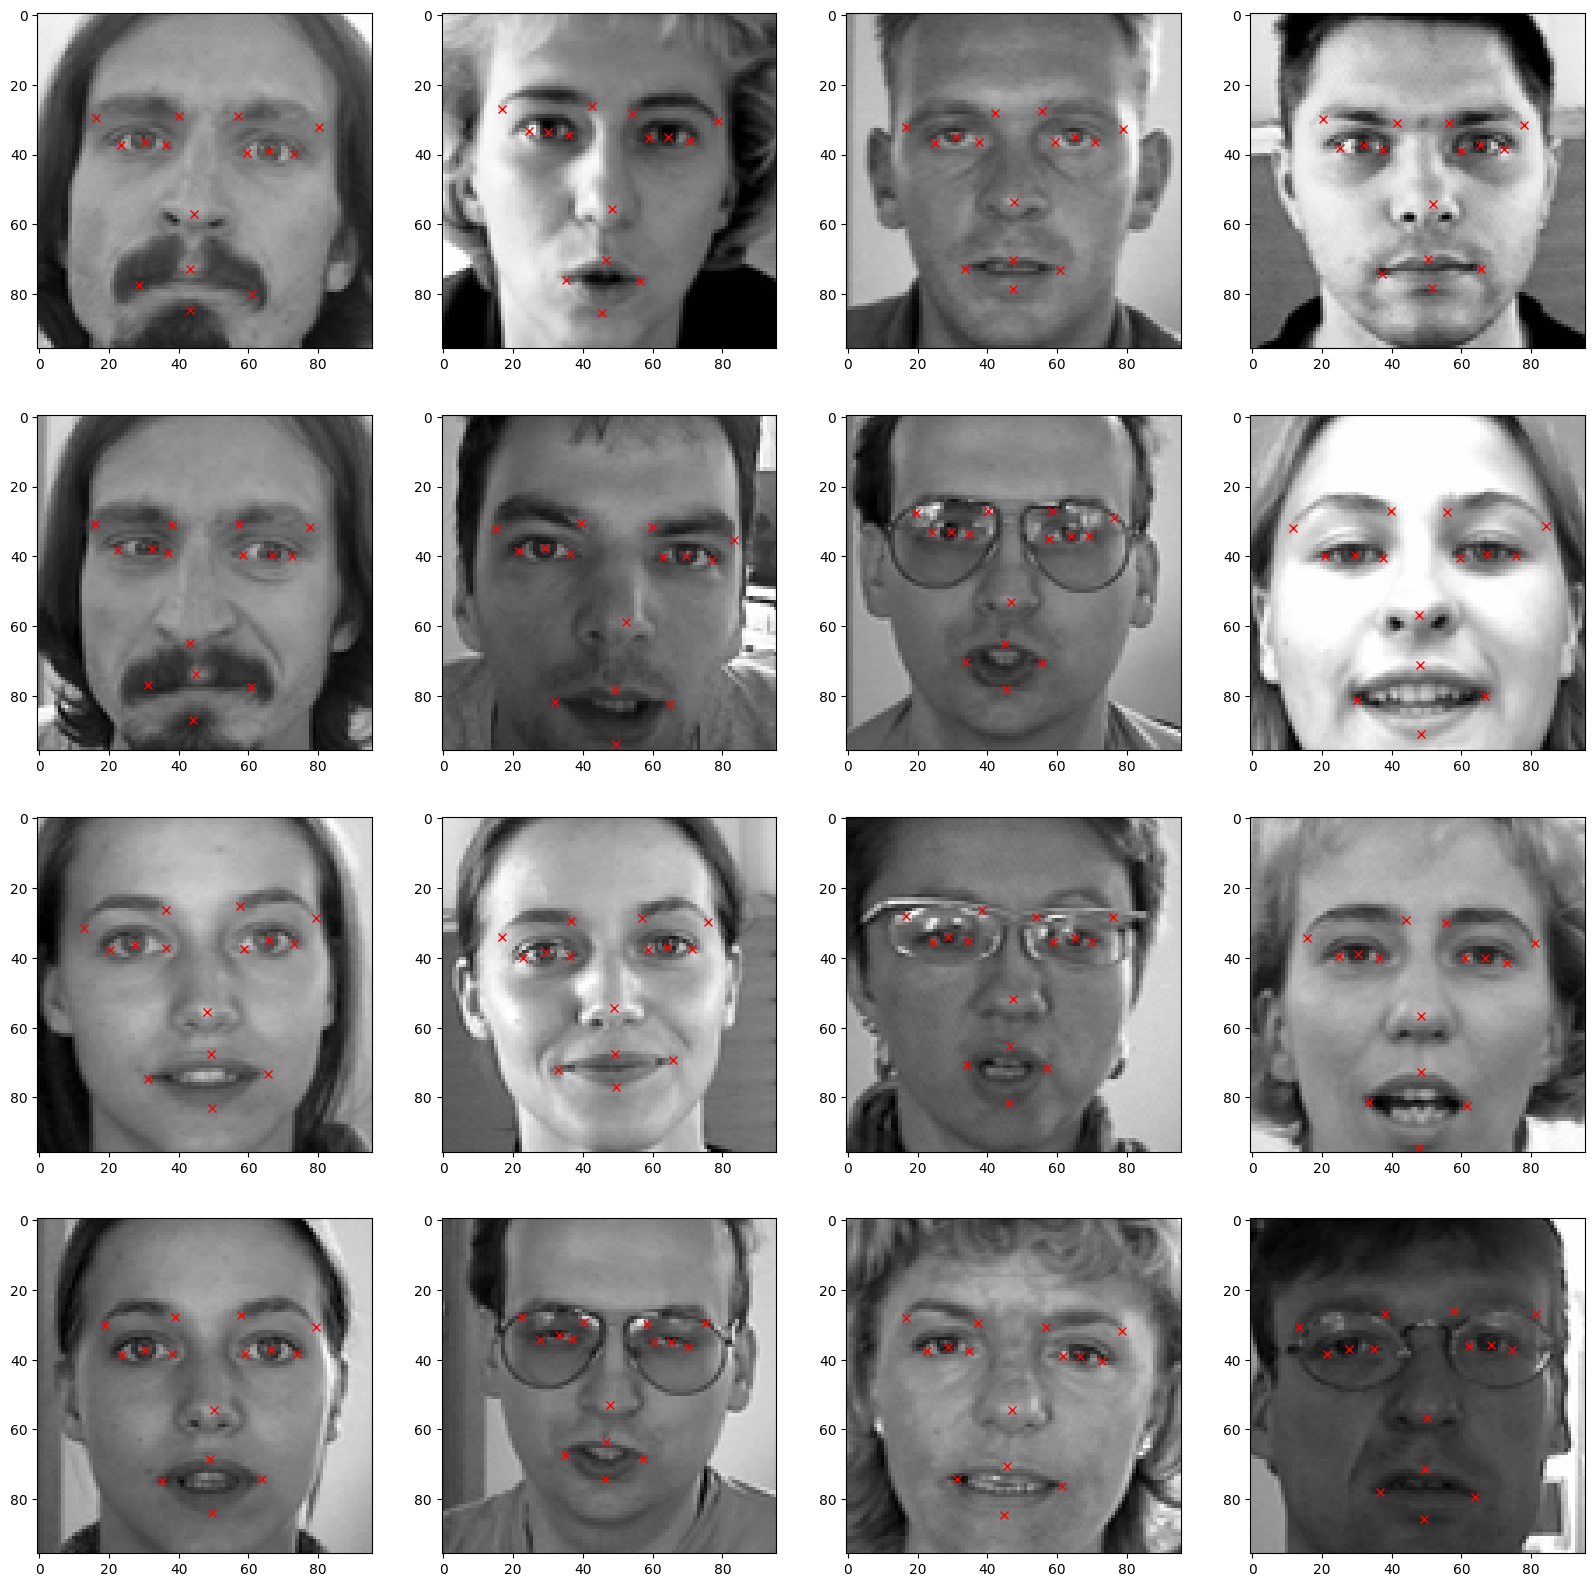

In [13]:
# more images in a grid format just for a sanity check
fig = plt.figure(figsize=(20, 20))

for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1)
    image = plt.imshow(keyfacial_df['Image'][i],cmap = 'gray')
    for j in range(1,31,2):
        plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'rx')

In [14]:
# Create a new copy of the dataframe
import copy
keyfacial_df_copy = copy.copy(keyfacial_df)

In [15]:
# Obtain the columns in the dataframe

columns = keyfacial_df_copy.columns[:-1]
columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y'],
      dtype='object')

In [16]:
# Horizontal Flip - flip the images along y axis
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x: np.flip(x, axis = 1))

# since we are flipping horizontally, y coordinate values would be the same
# Only x coordiante values would change, all we have to do is to subtract our initial x-coordinate values from width of the image(96)
for i in range(len(columns)):
  if i%2 == 0:
    keyfacial_df_copy[columns[i]] = keyfacial_df_copy[columns[i]].apply(lambda x: 96. - float(x) )

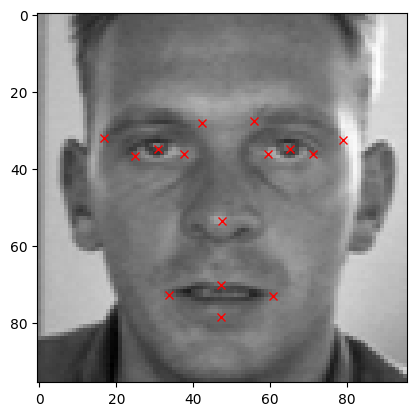

In [17]:
# Show the Original image
plt.imshow(keyfacial_df['Image'][2], cmap = 'gray')
for j in range(1, 31, 2):
        plt.plot(keyfacial_df.loc[2][j-1], keyfacial_df.loc[2][j], 'rx')

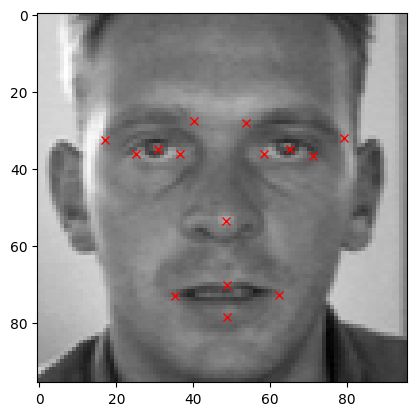

In [18]:
# Show the Horizontally flipped image
plt.imshow(keyfacial_df_copy['Image'][2],cmap='gray')
for j in range(1, 31, 2):
        plt.plot(keyfacial_df_copy.loc[2][j-1], keyfacial_df_copy.loc[2][j], 'rx')

In [19]:
# Concatenate the original dataframe with the augmented dataframe
augmented_df = np.concatenate((keyfacial_df, keyfacial_df_copy))

In [20]:
# Randomingly increasing the brightness of the images
# We multiply pixel values by random values between 1.5 and 2 to increase the brightness of the image
# we clip the value between 0 and 255

import random

keyfacial_df_copy = copy.copy(keyfacial_df)
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x:np.clip(random.uniform(1.5, 2)* x, 0.0, 255.0))
augmented_df = np.concatenate((augmented_df, keyfacial_df_copy))
augmented_df.shape

(6420, 31)

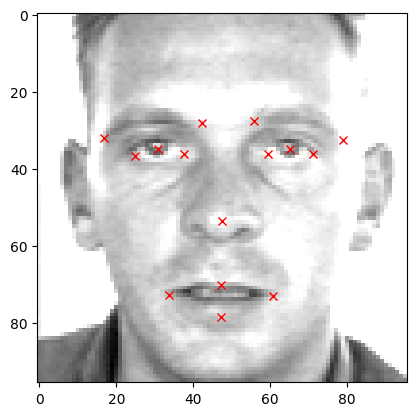

In [21]:
# Show Image with increased brightness

plt.imshow(keyfacial_df_copy['Image'][2], cmap='gray')
for j in range(1, 31, 2):
        plt.plot(keyfacial_df_copy.loc[2][j-1], keyfacial_df_copy.loc[2][j], 'rx')

In [22]:
keyfacial_df_copy = copy.copy(keyfacial_df)

In [23]:
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x: np.flip(x, axis = 0))

for i in range(len(columns)):
  if i%2 == 1:
    keyfacial_df_copy[columns[i]] = keyfacial_df_copy[columns[i]].apply(lambda x: 96. - float(x) )

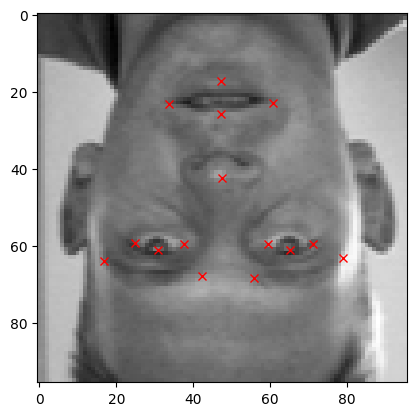

In [24]:
plt.imshow(keyfacial_df_copy['Image'][2], cmap='gray')
for j in range(1, 31, 2):
        plt.plot(keyfacial_df_copy.loc[2][j-1], keyfacial_df_copy.loc[2][j], 'rx')

**Part 3: *PERFORM DATA NORMALIZATION AND TRAINING DATA PREPARATION***

> Obtain the value of images which is present in the 31st column (since index start from 0, we refer to 31st column by 30)

> Normalize the images

> Create an empty array of shape (x, 96, 96, 1) to feed the model

> Convert the array type to float32

In [25]:
img = augmented_df[:,30]


img = img/255.

X = np.empty((len(img), 96, 96, 1))

# Iterate through the img list and add image values to the empty array after expanding it's dimension from (96, 96) to (96, 96, 1)
for i in range(len(img)):
  X[i,] = np.expand_dims(img[i], axis = 2)

X = np.asarray(X).astype(np.float32)
X.shape

(6420, 96, 96, 1)

In [26]:
# Obtain the value of x & y coordinates which are to used as target.
y = augmented_df[:,:30]
y = np.asarray(y).astype(np.float32)
y.shape

(6420, 30)

In [27]:
# Split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [28]:
print(X_train.shape)
print(X_test.shape)

(5136, 96, 96, 1)
(1284, 96, 96, 1)


***Part 6: *BUILD DEEP RESIDUAL NEURAL NETWORK KEY FACIAL POINTS DETECTION MODEL***
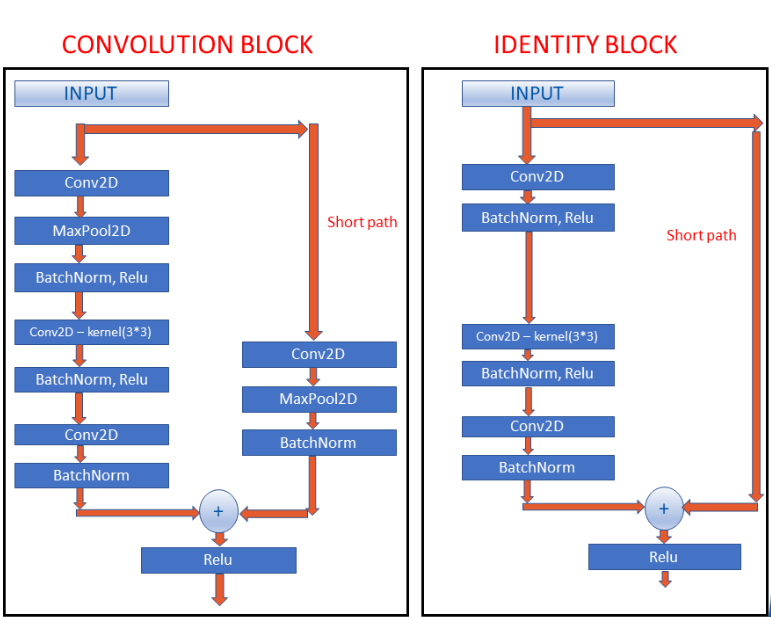

In [29]:
def res_block(X, filter, stage):

  # Convolutional_block
  X_copy = X

  # Bottleneck Block.
  f1 , f2, f3 = filter

  # Main Path
  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_conv_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = MaxPool2D((2,2))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, kernel_size = (3,3), strides =(1,1), padding = 'same', name ='res_'+str(stage)+'_conv_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_conv_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_c')(X)


  # Short path
  X_copy = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_conv_copy', kernel_initializer= glorot_uniform(seed = 0))(X_copy)
  X_copy = MaxPool2D((2,2))(X_copy)
  X_copy = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_copy')(X_copy)

  # ADD
  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  # Identity Block 1
  X_copy = X


  # Main Path
  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_1_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, kernel_size = (3,3), strides =(1,1), padding = 'same', name ='res_'+str(stage)+'_identity_1_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_identity_1_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_c')(X)

  # ADD
  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  # Identity Block 2
  X_copy = X


  # Main Path
  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_2_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, kernel_size = (3,3), strides =(1,1), padding = 'same', name ='res_'+str(stage)+'_identity_2_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_identity_2_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_c')(X)

  # ADD
  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  return X

In [30]:
input_shape = (96, 96, 1)

# Input tensor shape
X_input = Input(input_shape)

# Zero-padding
X = ZeroPadding2D((3,3))(X_input)

# 1 - stage
X = Conv2D(64, (7,7), strides= (2,2), name = 'conv1', kernel_initializer= glorot_uniform(seed = 0))(X)
X = BatchNormalization(axis =3, name = 'bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3,3), strides= (2,2))(X)

# 2 - stage
X = res_block(X, filter= [64,64,256], stage= 2)

# 3 - stage
X = res_block(X, filter= [128,128,512], stage= 3)


# Average Pooling
X = AveragePooling2D((2,2), name = 'Averagea_Pooling')(X)

# Final layer
X = Flatten()(X)
X = Dense(4096, activation = 'relu')(X)
X = Dropout(0.2)(X)
X = Dense(2048, activation = 'relu')(X)
X = Dropout(0.1)(X)
X = Dense(30, activation = 'relu')(X)


model_1_facialKeyPoints = Model( inputs= X_input, outputs = X)
model_1_facialKeyPoints.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 102,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 48, 48,    │      3,200 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 48, 48,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 23, 23,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 18,016,286 (68.73 MB)

 Trainable params: 18,007,710 (68.69 MB)

 Non-trainable params: 8,576 (33.50 KB)

# Part 4: COMPILE AND TRAIN KEY FACIAL POINTS DETECTION DEEP LEARNING MODEL

In [31]:
adam = tf.keras.optimizers.Adam(learning_rate = 0.0001, beta_1 = 0.9, beta_2 = 0.999, amsgrad = False)
model_1_facialKeyPoints.compile(loss = "mean_squared_error", optimizer = adam , metrics = ['accuracy'])

In [32]:
#save the best model with least validation loss
#checkpoint = ModelCheckpoint(
    #filepath="FacialKeyPoints_weights.keras",
    #verbose=1,
    #save_best_only=True
#)

In [33]:
checkpointer = ModelCheckpoint(
    filepath="FacialKeyPoints.keras",
    verbose=1,
    save_best_only=True
)

In [34]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model_1_facialKeyPoints.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.2,
    callbacks=[checkpointer, early_stopping]
)


Epoch 1/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4657 - loss: 968.6179
Epoch 1: val_loss improved from None to 1892.94336, saving model to FacialKeyPoints.keras

Epoch 1: finished saving model to FacialKeyPoints.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.5489 - loss: 479.8871 - val_accuracy: 0.7053 - val_loss: 1892.9434
Epoch 2/5
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6020 - loss: 206.0157
Epoch 2: val_loss improved from 1892.94336 to 1212.33105, saving model to FacialKeyPoints.keras

Epoch 2: finished saving model to FacialKeyPoints.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.5879 - loss: 201.9192 - val_accuracy: 0.7053 - val_loss: 1212.3311
Epoch 3/5
63/65 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5973 - loss: 171.6178
Epoch 3: val_loss improved from 1212.33105 to 757.58942, saving model to FacialKeyPoints.keras

Epoch 3: finished saving model to FacialKeyPoints.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - ac

In [35]:
# save the model architecture to json file for future use
model_json = model_1_facialKeyPoints.to_json()
with open("FacialKeyPoints-model.json","w") as json_file:
  json_file.write(model_json)

# Part 5: ASSESS TRAINED KEY FACIAL POINTS DETECTION MODEL PERFORMANCE

In [36]:
model_1_facialKeyPoints = tf.keras.models.load_model(
    "FacialKeyPoints.keras"
)

In [37]:
# Evaluate the model
result = model_1_facialKeyPoints.evaluate(X_test, y_test)
print("Accuracy : {}".format(result[1]))

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7087 - loss: 474.6489
Accuracy : 0.7087227702140808


In [38]:
# Get the model keys
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

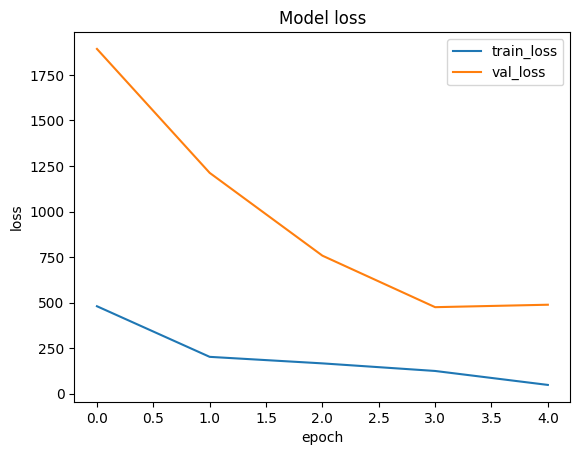

In [39]:
# Plot the training artifacts
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()

#  Part 6: IMPORT & EXPLORE DATASET FOR FACIAL EXPRESSION DETECTION

In [40]:
facialexpression_df = pd.read_csv(
    "/content/drive/My Drive/Emotion AI Dataset/icml_face_data.csv"
)

facialexpression_df

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
3,2,20 17 19 21 25 38 42 42 46 54 56 62 63 66 82 1...
4,3,77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...
...,...,...
24563,3,0 39 81 80 104 97 51 64 68 46 41 67 53 68 70 5...
24564,0,181 177 176 156 178 144 136 132 122 107 131 16...
24565,3,178 174 172 173 181 188 191 194 196 199 200 20...
24566,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...


In [41]:
facialexpression_df[' pixels'][0] # String format

'70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119 115 110 98 91 84 84 90 99 110 126 143 153 158 171 169 172 169 165 129 110 113 107 95 79 66 62 56 57 61 52 43 41 65 61 58 57 56 69 75 70 65 56 54 105 146 154 151 151 155 155 150 147 147 148 152 158 164 172 177 182 186 189 188 190 188 180 167 116 95 103 97 77 72 62 55 58 54 56 52 44 50 43 54 64 63 71 68 64 52 66 119 156 161 164 163 164 167 168 170 174 175 176 178 179 183 187 190 195 197 198 197 198 195 191 190 145 86 100 90 65 57 60 54 51 41 49 56 47 38 44 63 55 46 52 54 55 83 138 157 158 165 168 172 171 173 176 179 179 180 182 185 187 189 189 192 197 200 199 196 198 200 198 197 177 91 87 96 58 58 59 51 42 37 41 47 45 37 35 36 30 41 47 59 94 141 159 161 161 164 170 171 172 176 178 179 182 183 183 187 189 192 192 194 195 200 200 199 199 200 201 197 193 111 71 108 69 55 61 51 42 43 56 54 44 24 29 31 45 61 72 100 136 150 159 163 162 163 170 172 171 174 177 177 180 187 186 187 189 192 192 194 195 196 197 199 200 201 200 197 201 137 58 98 92

In [42]:
# function to convert pixel values in string format to array format
def string2array(x):
  return np.array(x.split(' ')).reshape(48, 48, 1).astype('float32')

In [43]:
# Resize images from (48, 48) to (96, 96)
def resize(x):

  img = x.reshape(48, 48)
  return cv2.resize(img, dsize=(96, 96), interpolation = cv2.INTER_CUBIC)

In [44]:
facialexpression_df[' pixels'] = facialexpression_df[' pixels'].apply(lambda x: string2array(x))

In [45]:
facialexpression_df[' pixels'] = facialexpression_df[' pixels'].apply(lambda x: resize(x))

In [46]:
facialexpression_df.head()

,emotion,pixels
0,0,"[[69.316925, 73.03865, 79.13719, 84.17186, 85...."
1,0,"[[151.09435, 150.91393, 150.65791, 148.96367, ..."
2,2,"[[23.061905, 25.50914, 29.47847, 33.99843, 36...."
3,2,"[[20.083221, 19.079437, 17.398712, 17.158691, ..."
4,3,"[[76.26172, 76.54747, 77.001785, 77.7672, 78.4..."


In [47]:
# check for the presence of null values in the data frame
facialexpression_df.isnull().sum()

,0
emotion,0
pixels,0


In [48]:
label_to_text = {0:'anger', 1:'disgust', 2:'sad', 3:'happiness', 4: 'surprise'}

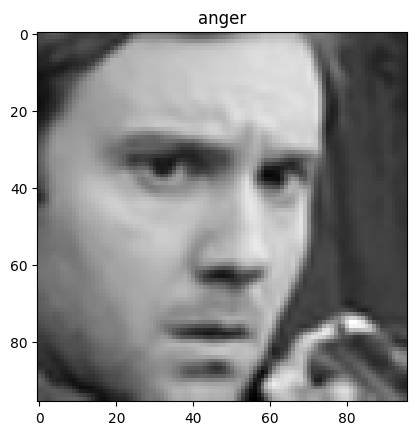

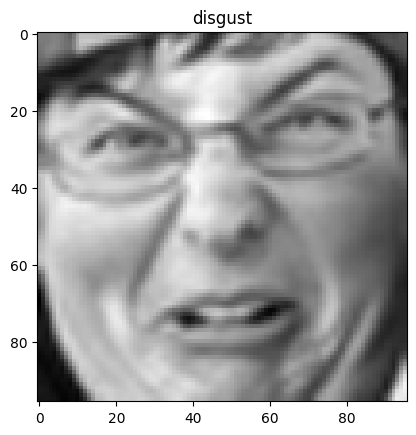

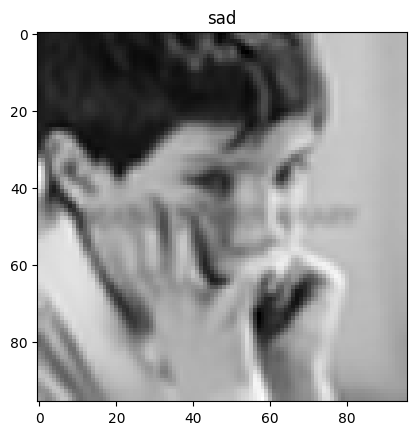

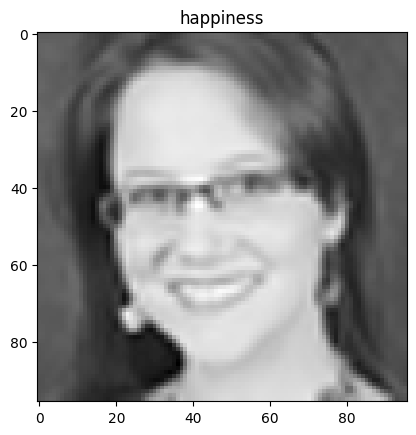

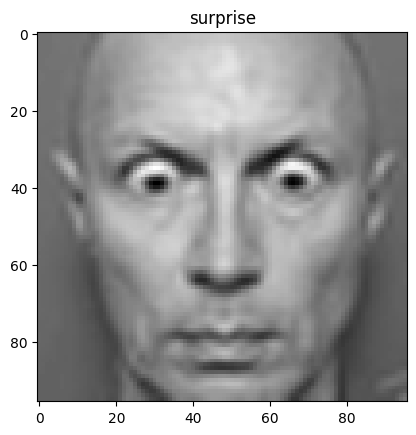

In [49]:
# visualize images and plot labels
emotions = [0, 1, 2, 3, 4]

for i in emotions:
  data = facialexpression_df[facialexpression_df['emotion'] == i][:1]
  img = data[' pixels'].item()
  img = img.reshape(96, 96)
  plt.figure()
  plt.title(label_to_text[i])
  plt.imshow(img, cmap = 'gray')

In [50]:
#Plot bar chart to outline how many samples (images) are present per emotion
facialexpression_df.emotion.value_counts().index

Index([3, 2, 0, 4, 1], dtype='int64', name='emotion')

In [51]:
facialexpression_df.emotion.value_counts()

,count
emotion,
3,8989
2,6077
0,4953
4,4002
1,547


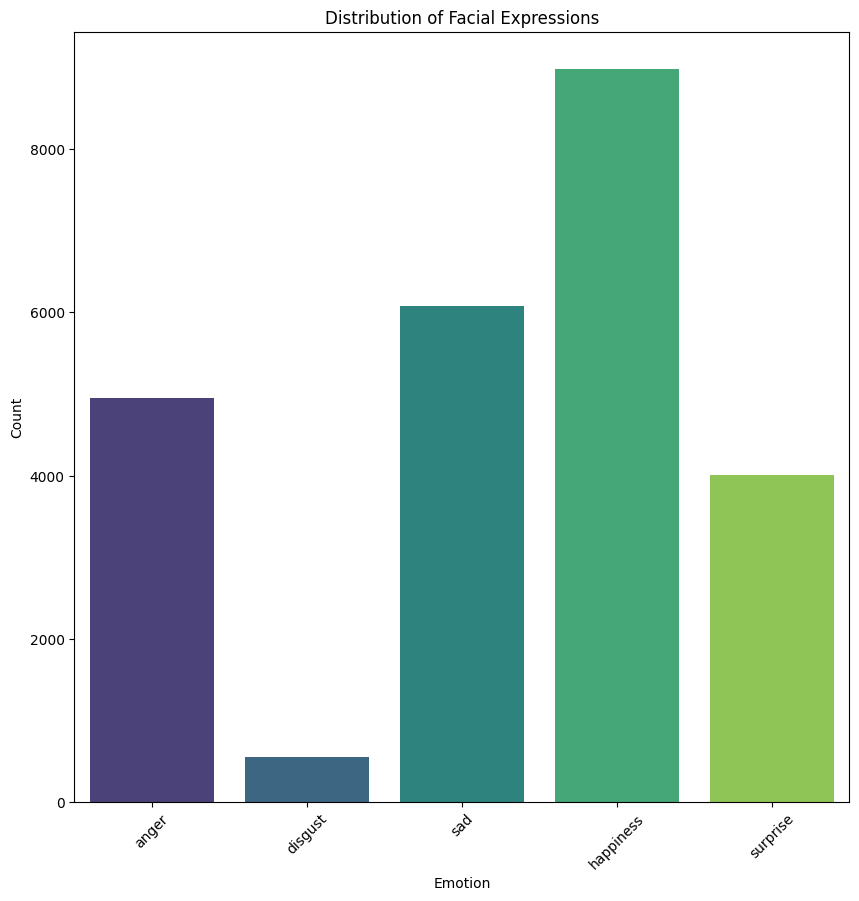

In [52]:
plt.figure(figsize = (10,10))
sns.barplot(x = facialexpression_df.emotion.value_counts().index, y = facialexpression_df.emotion.value_counts(), palette='viridis')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Facial Expressions')
plt.xticks(list(label_to_text.keys()), list(label_to_text.values()), rotation=45)
plt.show()

# Part 7: PERFORM DATA PREPARATION AND IMAGE AUGMENTATION

In [53]:
# split the dataframe in to features and labels
from keras.utils import to_categorical

X = facialexpression_df[' pixels']
y = to_categorical(facialexpression_df['emotion'])


In [54]:
X = np.stack(X, axis = 0)
X = X.reshape(24568, 96, 96, 1)

print(X.shape, y.shape)

(24568, 96, 96, 1) (24568, 5)


In [55]:
# split the dataframe in to train, test and validation data frames

X_train, X_Test, y_train, y_Test = train_test_split(X, y, test_size = 0.1, shuffle = True)
X_val, X_Test, y_val, y_Test = train_test_split(X_Test, y_Test, test_size = 0.5, shuffle = True)


In [56]:
# image pre-processing
X_train = X_train/255
X_val   = X_val /255
X_Test  = X_Test/255

In [57]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    brightness_range=(0.8, 1.2),
)

# Part 8: BUILD AND TRAIN DEEP LEARNING MODEL FOR FACIAL EXPRESSION CLASSIFICATION

In [58]:
input_shape = (96, 96, 1)

# Input tensor shape
X_input = Input(input_shape)

# Zero-padding
X = ZeroPadding2D((3, 3))(X_input)

# 1 - stage
X = Conv2D(64, (7, 7), strides= (2, 2), name = 'conv1', kernel_initializer= glorot_uniform(seed = 0))(X)
X = BatchNormalization(axis =3, name = 'bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3, 3), strides= (2, 2))(X)

# 2 - stage
X = res_block(X, filter= [64, 64, 256], stage= 2)

# 3 - stage
X = res_block(X, filter= [128, 128, 512], stage= 3)

# 4 - stage
# X = res_block(X, filter= [256, 256, 1024], stage= 4)

# Average Pooling
X = AveragePooling2D((4, 4), name = 'Averagea_Pooling')(X)

# Final layer
X = Flatten()(X)
X = Dense(5, activation = 'softmax', name = 'Dense_final', kernel_initializer= glorot_uniform(seed=0))(X)

model_2_emotion = Model( inputs= X_input, outputs = X, name = 'Resnet18')

model_2_emotion.summary()

Model: "Resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 102, 102,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 48, 48,    │      3,200 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 48, 48,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 48, 48,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 23, 23,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_5[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_6[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_20[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d_5[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_21[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 1,174,021 (4.48 MB)

 Trainable params: 1,165,445 (4.45 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [59]:
# train the network
model_2_emotion.compile(optimizer = "Adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [60]:
# facial key points model was saved as follows: FacialKeyPoints_weights.hdf5 and FacialKeyPoints-model.json

# using early stopping to exit training if validation loss is not decreasing even after certain epochs (patience)
earlystopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=20
)

# save the best model with lower validation loss
checkpointer = ModelCheckpoint(
    filepath="FacialExpression.keras",
    verbose=1,
    save_best_only=True
)

In [61]:
history = model_2_emotion.fit(train_datagen.flow(X_train, y_train, batch_size=64),
	validation_data=(X_val, y_val), steps_per_epoch=len(X_train) // 64,
	epochs= 2, callbacks=[checkpointer, earlystopping])

Epoch 1/2
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3365 - loss: 1.6885
Epoch 1: val_loss improved from None to 1.44009, saving model to FacialExpression.keras

Epoch 1: finished saving model to FacialExpression.keras
345/345 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - accuracy: 0.3679 - loss: 1.4982 - val_accuracy: 0.2728 - val_loss: 1.4401
Epoch 2/2
  1/345 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.4062 - loss: 1.4158
Epoch 2: val_loss did not improve from 1.44009
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4062 - loss: 1.4158 - val_accuracy: 0.2443 - val_loss: 1.4413


In [62]:
# saving the model architecture to json file for future use
model_json = model_2_emotion.to_json()
with open("FacialExpression-model.json","w") as json_file:
  json_file.write(model_json)

# Part 9: ASSESS THE PERFORMANCE OF TRAINED FACIAL EXPRESSION CLASSIFIER MODEL

In [63]:
import shutil

shutil.copy(
    "/content/FacialExpression.keras",
    "/content/drive/My Drive/Emotion AI Dataset/FacialExpression.keras"
)

'/content/drive/My Drive/Emotion AI Dataset/FacialExpression.keras'

In [64]:
import os

print(os.listdir('/content'))

['.config', 'keypoint_server.log', 'FacialKeyPoints.keras', 'server.log', 'FacialExpression.keras', '.gradio', 'FacialKeyPoints-model.json', 'drive', 'FacialExpression-model.json', 'emotion_server.log', 'sample_data']


In [65]:
import os

print("Files in /content:")
print(os.listdir("/content"))

print("\nFiles in Drive Dataset:")
print(os.listdir("/content/drive/My Drive/Emotion AI Dataset"))

Files in /content:
['.config', 'keypoint_server.log', 'FacialKeyPoints.keras', 'server.log', 'FacialExpression.keras', '.gradio', 'FacialKeyPoints-model.json', 'drive', 'FacialExpression-model.json', 'emotion_server.log', 'sample_data']

Files in Drive Dataset:
['augmented.csv', 'data.csv', 'detection.json', 'facial_detection.ipynb', 'face_detection.json', 'emotion.json', 'server.log', 'icml_face_data.csv', 'models.config', 'test.csv', 'training.csv', 'weights.h5', 'weights.hdf5', 'weights_emotion.hdf5', 'weights_emotions.hdf5', 'weights_keypoint.hdf5', 'FacialExpression.keras']


In [66]:
with open("/content/FacialExpression-model.json", "r") as json_file:
    json_savedModel = json_file.read()

# Rebuild the model architecture
model_2_emotion = tf.keras.models.model_from_json(json_savedModel)

# Load the correct trained weights
model_2_emotion.load_weights(
    "/content/drive/My Drive/Emotion AI Dataset/weights_emotions.hdf5"
)

# Compile the model
model_2_emotion.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Evaluate
score = model_2_emotion.evaluate(
    X_Test,
    y_Test,
    verbose=1
)

print("Test Accuracy:", score[1])

39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8804 - loss: 0.3411
Test Accuracy: 0.8803905844688416


In [67]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [68]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [69]:
emotion_history = model_2_emotion.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.2,
    callbacks=[checkpointer, earlystopping]
)

Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8802 - loss: 0.3257
Epoch 1: val_loss improved from 1.44009 to 0.80430, saving model to FacialExpression.keras

Epoch 1: finished saving model to FacialExpression.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.8778 - loss: 0.3286 - val_accuracy: 0.7341 - val_loss: 0.8043
Epoch 2/5
275/277 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9263 - loss: 0.1966
Epoch 2: val_loss improved from 0.80430 to 0.57982, saving model to FacialExpression.keras

Epoch 2: finished saving model to FacialExpression.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9219 - loss: 0.2052 - val_accuracy: 0.8040 - val_loss: 0.5798
Epoch 3/5
275/277 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9509 - loss: 0.1353
Epoch 3: val_loss improved from 0.57982 to 0.50947, saving model to FacialExpression.keras

Epoch 3: finished saving model to FacialExpression.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.94

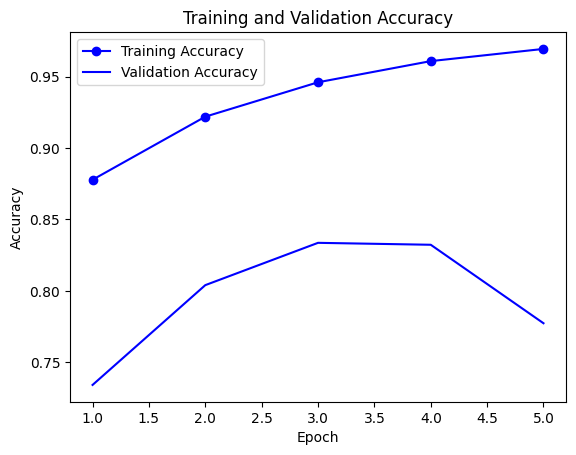

In [70]:
accuracy = emotion_history.history['accuracy']
val_accuracy = emotion_history.history['val_accuracy']

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b-', label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [71]:
# predicted_classes = model.predict_classes(X_test)
predicted_classes = np.argmax(model_2_emotion.predict(X_Test), axis=-1)
y_true = np.argmax(y_Test, axis=-1)

39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step


<Axes: >

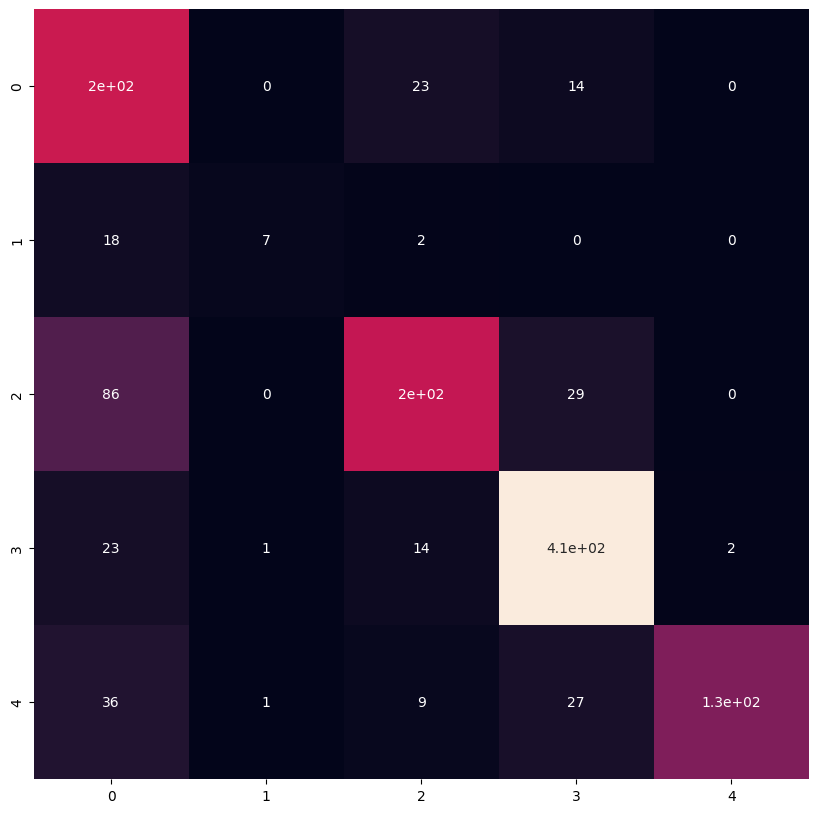

In [72]:
cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize = (10, 10))
sns.heatmap(cm, annot = True, cbar = False)

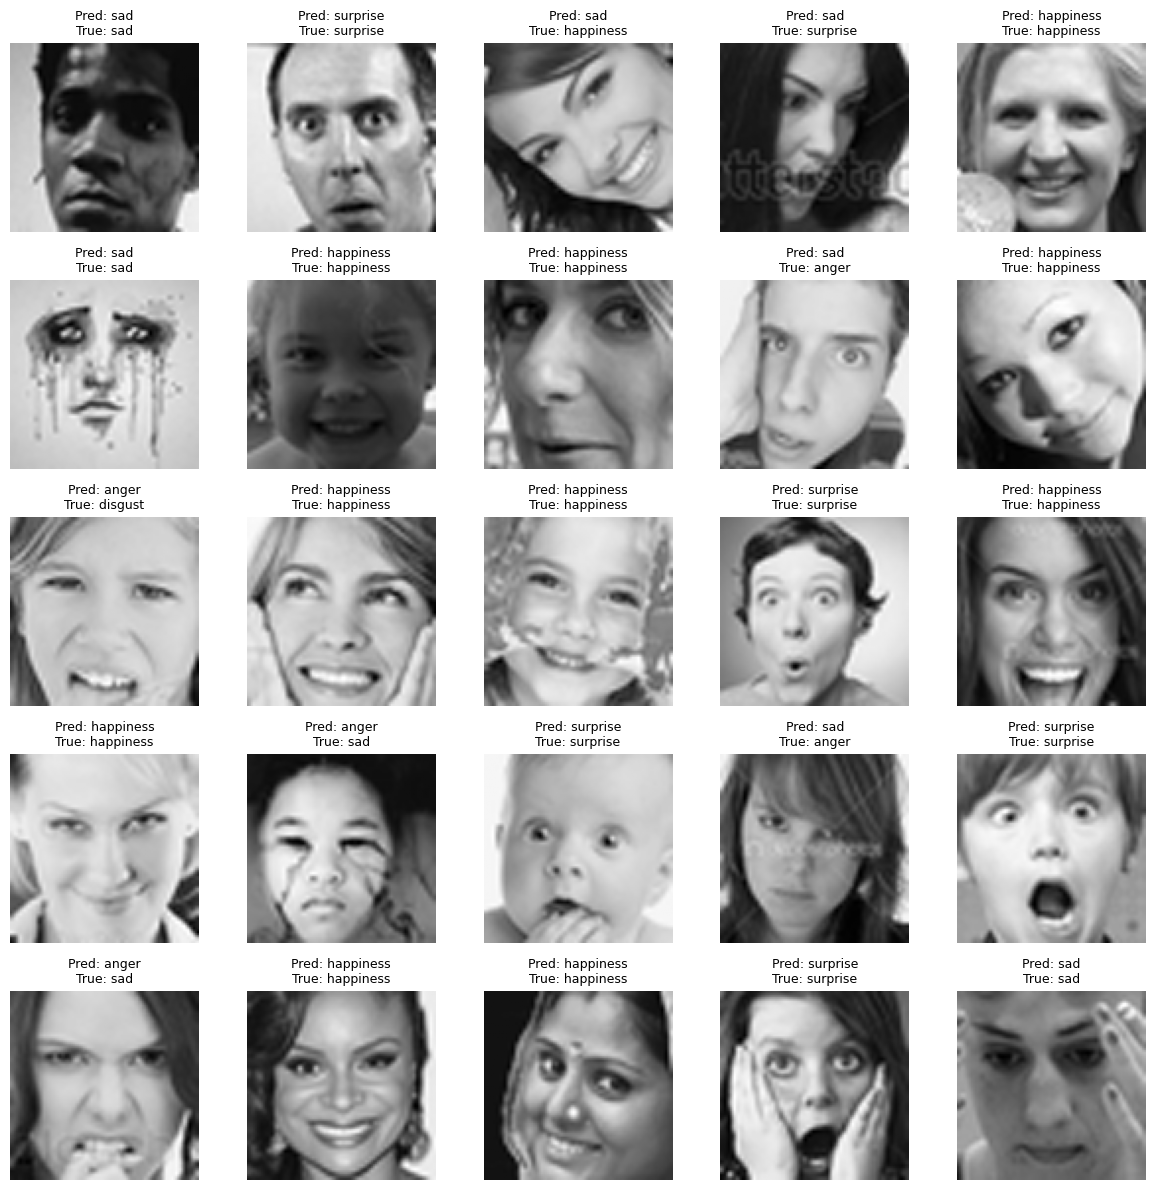

In [73]:
plt.figure(figsize=(12, 12))

for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(X_Test[i].reshape(96, 96), cmap='gray')

    predicted_label = label_to_text[predicted_classes[i]]
    true_label = label_to_text[y_true[i]]

    plt.title(
        f"Pred: {predicted_label}\nTrue: {true_label}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [74]:
print(classification_report(
    y_true,
    predicted_classes,
    target_names=[
        'anger',
        'disgust',
        'sad',
        'happiness',
        'surprise'
    ]
))

              precision    recall  f1-score   support

       anger       0.55      0.85      0.67       240
     disgust       0.78      0.26      0.39        27
         sad       0.80      0.63      0.71       311
   happiness       0.85      0.91      0.88       447
    surprise       0.98      0.64      0.78       204

    accuracy                           0.77      1229
   macro avg       0.79      0.66      0.68      1229
weighted avg       0.80      0.77      0.77      1229



# PART 10: COMBINE BOTH FACIAL EXPRESSION AND KEY POINTS DETECTION MODELS

In [75]:
def predict(X_test):

  # Making prediction from the keypoint model
  df_predict = model_1_facialKeyPoints.predict(X_test)

  # Making prediction from the emotion model
  df_emotion = np.argmax(model_2_emotion.predict(X_test), axis=-1)

  # Reshaping array from (856,) to (856,1)
  df_emotion = np.expand_dims(df_emotion, axis = 1)

  # Converting the predictions into a dataframe
  df_predict = pd.DataFrame(df_predict, columns= columns)

  # Adding emotion into the predicted dataframe
  df_predict['emotion'] = df_emotion

  return df_predict

In [76]:
df_predict = predict(X_test)
df_predict.head()

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,emotion
0,24.960707,24.865263,43.126381,26.346355,27.982046,26.040087,22.013563,26.074207,27.338053,26.288364,...,39.824276,26.841267,53.234364,41.320267,53.790882,32.478226,51.312508,33.908047,56.699768,3
1,23.322935,24.394949,43.764885,25.749063,26.563900,25.589401,19.702126,25.627247,27.182961,25.918507,...,39.017208,25.288651,52.296535,41.548115,53.068722,31.985027,50.117451,33.373127,55.992783,3
2,26.764275,25.146502,42.190804,26.657057,29.298693,26.451050,24.319084,26.424091,27.576839,26.610546,...,40.469143,28.596365,54.035416,40.755100,54.252224,33.057186,52.140118,34.344208,57.299076,3
3,24.731701,24.679577,43.026119,26.086178,27.546160,25.882269,21.424994,25.966869,27.219301,26.011696,...,39.579708,26.493883,52.712276,41.152546,53.531796,32.387493,50.804638,33.724644,56.322128,0
4,24.597309,24.398321,42.244045,25.822245,27.519112,25.660702,21.588919,25.730356,26.953152,25.846909,...,39.150127,26.459394,52.447872,40.472847,52.897655,31.954523,50.258305,33.421886,55.752308,0


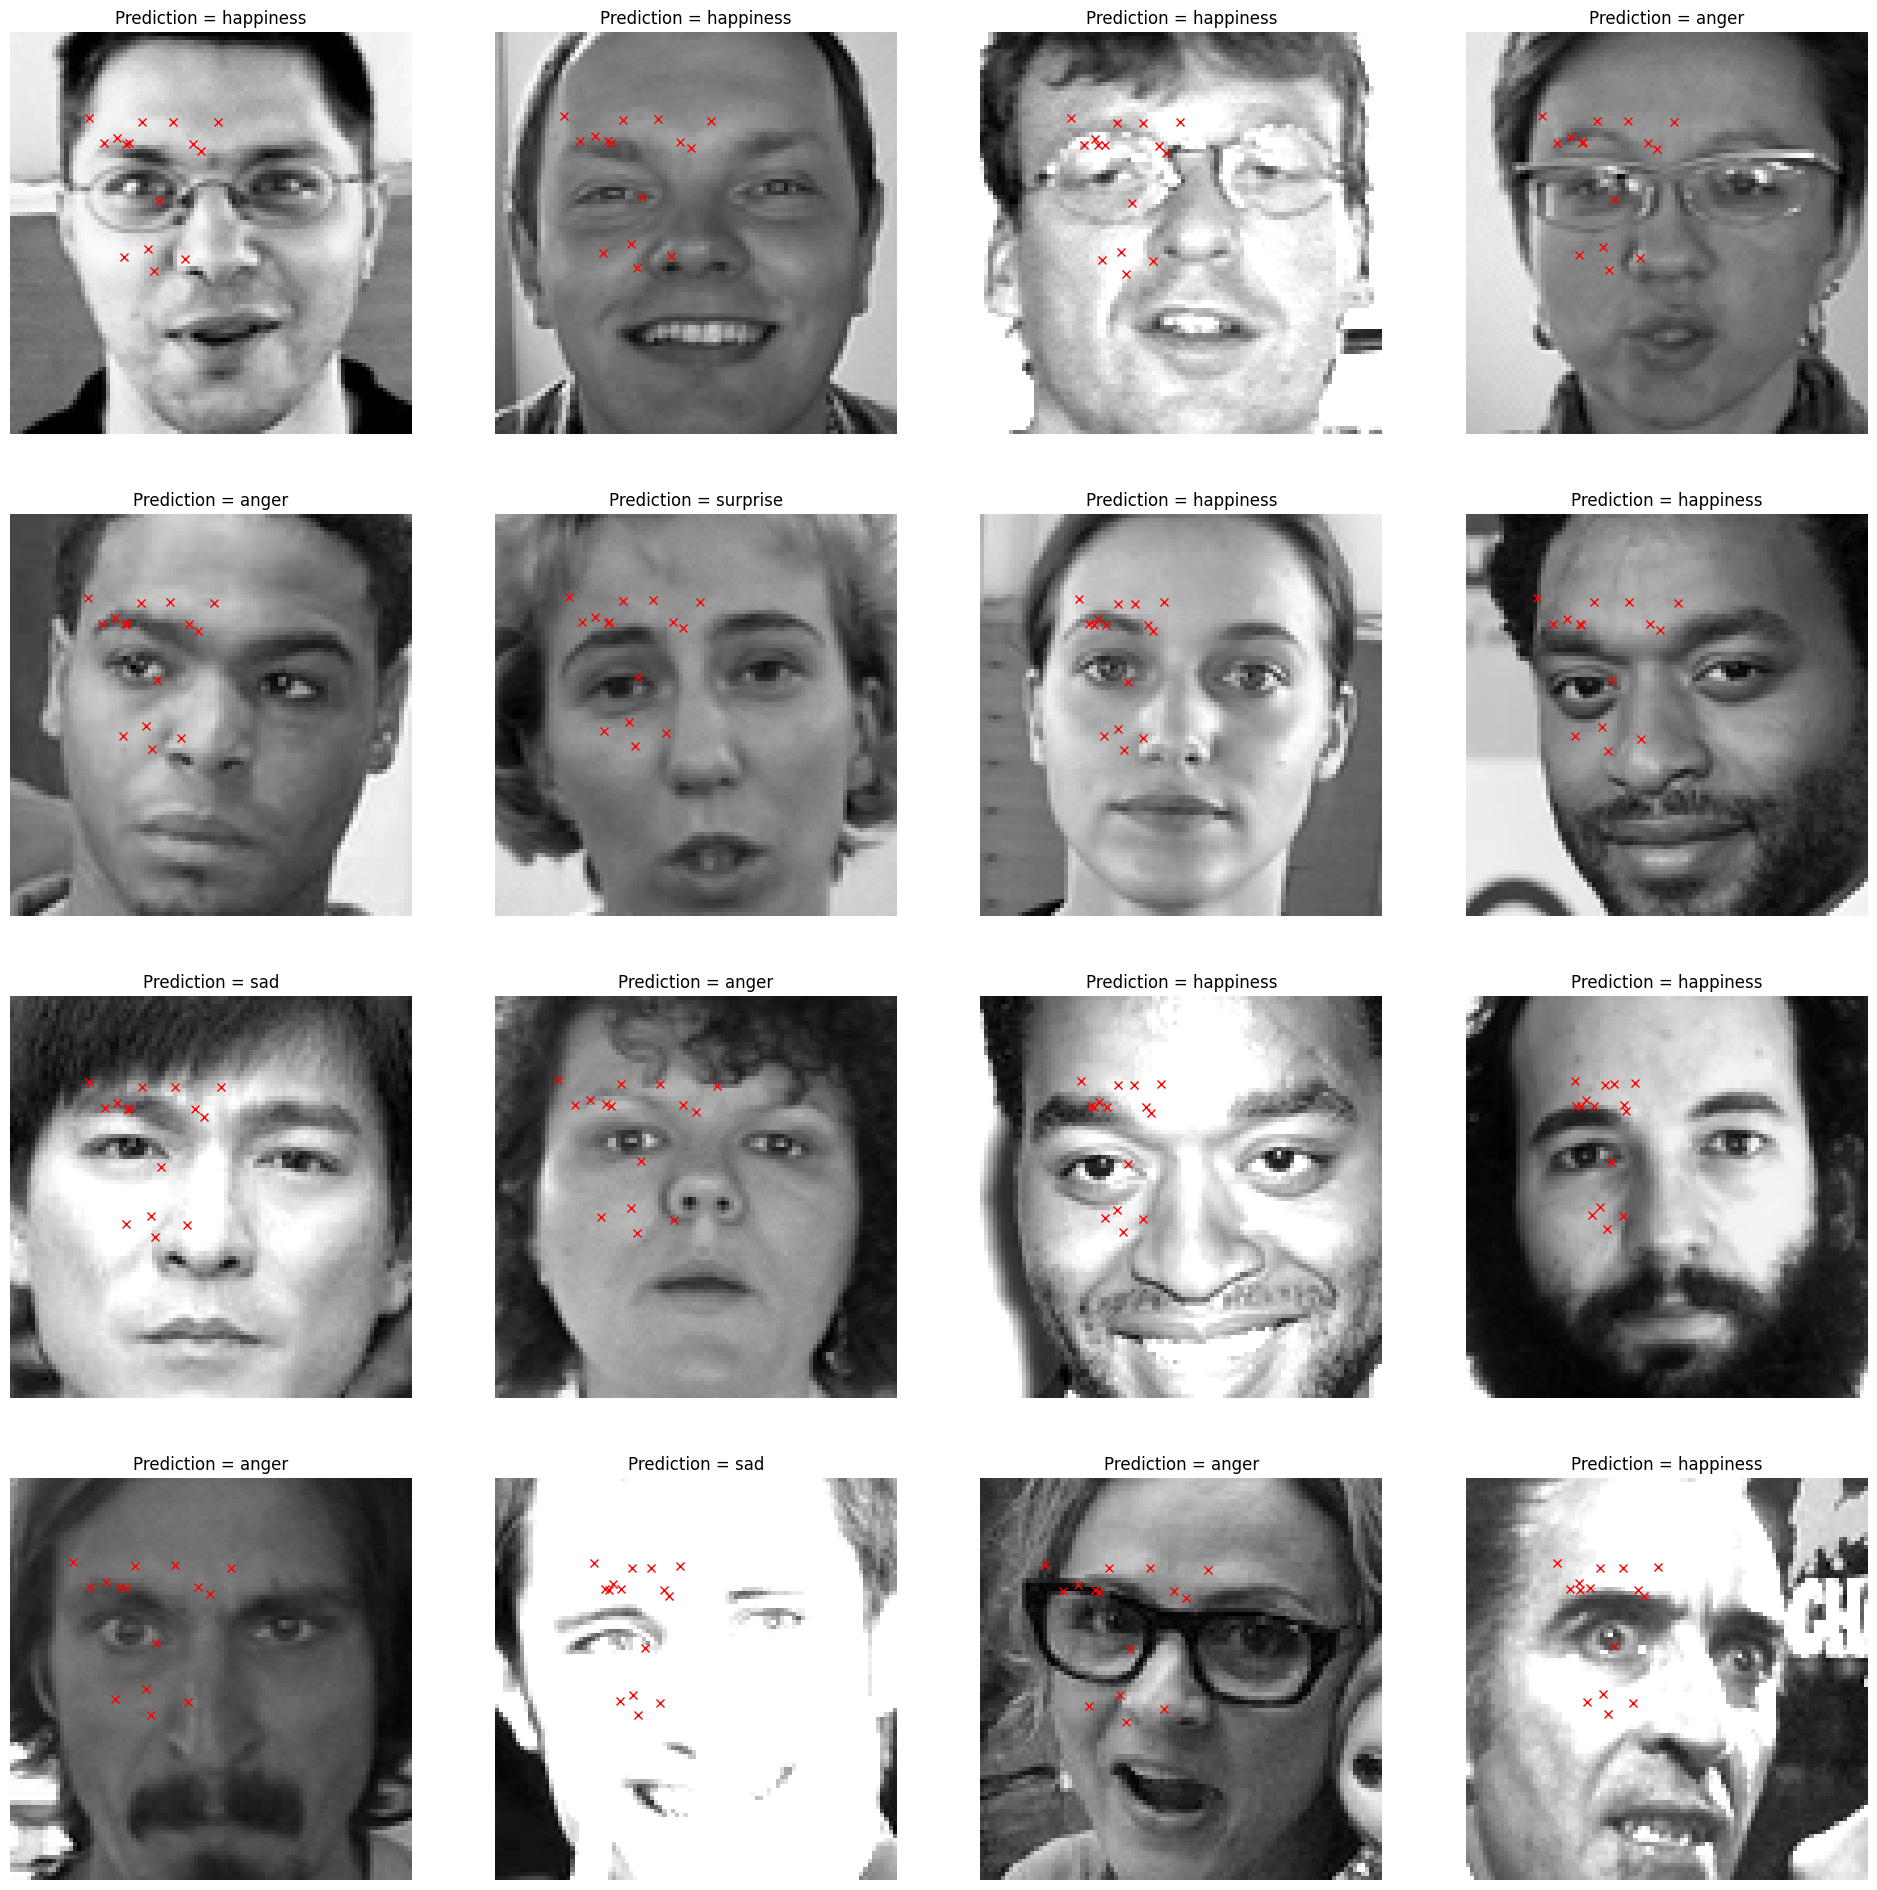

In [77]:
# Plotting the test images and their predicted keypoints and emotions

fig, axes = plt.subplots(4, 4, figsize = (24, 24))
axes = axes.ravel()

for i in range(16):

    axes[i].imshow(X_test[i].squeeze(),cmap='gray')
    axes[i].set_title('Prediction = {}'.format(label_to_text[df_predict['emotion'][i]]))
    axes[i].axis('off')
    for j in range(1,31,2):
            axes[i].plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'rx')


In [78]:
import os
import shutil

def deploy(directory, model, version=1):

    model_dir = directory
    export_path = os.path.join(model_dir, str(version))

    print(f"Export path = {export_path}\n")

    # Remove old version if it already exists
    if os.path.isdir(export_path):
        print("Model version already exists, removing it...\n")
        shutil.rmtree(export_path)

    # Export model as TensorFlow SavedModel
    model.export(export_path)

    print("Model exported successfully.")

    os.environ["MODEL_DIR"] = model_dir

# Part 11: SERVE THE MODEL USING TENSORFLOW SERVING

In [79]:
!which tensorflow_model_server

/usr/bin/tensorflow_model_server


In [80]:
# Let's add tensorflow-model-server package to our list of packages
!echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | tee /etc/apt/sources.list.d/tensorflow-serving.list && \
curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | apt-key add -
!apt update

deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: apt-key is deprecated. Manage keyring files in trusted.gpg.d instead (see apt-key(8)).
100  2943  100  2943    0     0   7530      0 --:--:-- --:--:-- --:--:--  7546
OK
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://storage.googleapis.com/tensorflow-serving-apt stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:7 http://archive.ubuntu.com/ubunt

In [81]:
# Let's install tensorflow model server
!apt-get install tensorflow-model-server

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tensorflow-model-server is already the newest version (2.20.0).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.


In [82]:
deploy('/facial_keypoints_model', model_1_facialKeyPoints)

Export path = /facial_keypoints_model/1

Model version already exists, removing it...

Saved artifact at '/facial_keypoints_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  139908338804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338808976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338805712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338806096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338808592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338807440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338808784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908338809168: TensorSpec(shape=(), dtype=tf.resource, nam

In [83]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4500 \
  --model_name=facial_keypoints \
  --model_base_path="/facial_keypoints_model" \
  >server.log 2>&1

In [84]:
!tail server.log

In [85]:
deploy('/emotion_model', model_2_emotion)

Export path = /emotion_model/1

Model version already exists, removing it...

Saved artifact at '/emotion_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139905387683216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905387685136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908751929616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908751929232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905387683600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905387682256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908751927312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908751929424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139908751929040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1399087

In [86]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4000 \
  --model_name=emotion_model \
  --model_base_path="/emotion_model" \
  >emotion_server.log 2>&1

In [87]:
!tail emotion_server.log

In [89]:
# Prepare 3 test images for TensorFlow Serving
import json
data = json.dumps({
    "signature_name": "serving_default",
    "instances": X_Test[0:3].tolist()
})

print('Data: {} ... {}'.format(
    data[:50],
    data[-52:]
))

Data: {"signature_name": "serving_default", "instances": ... 675], [1.0253502130508423], [1.0274924039840698]]]]}


In [90]:
!pip install -q requests

In [91]:
import requests
import json
import numpy as np
import pandas as pd

# Function to make predictions from deployed models
def response(data):

    headers = {
        "content-type": "application/json"
    }

    # Facial Keypoints Model
    keypoint_response = requests.post(
        "http://localhost:4500/v1/models/facial_keypoints/versions/1:predict",
        data=data,
        headers=headers
    )

    keypoint_predictions = json.loads(
        keypoint_response.text
    )["predictions"]

    # Emotion Model
    emotion_response = requests.post(
        "http://localhost:4000/v1/models/emotion_model/versions/1:predict",
        data=data,
        headers=headers
    )

    emotion_predictions = json.loads(
        emotion_response.text
    )["predictions"]

    # Get predicted emotion class
    df_emotion = np.argmax(
        emotion_predictions,
        axis=1
    )

    # Reshape from (n,) to (n, 1)
    df_emotion = np.expand_dims(
        df_emotion,
        axis=1
    )

    # Convert keypoint predictions to DataFrame
    df_predict = pd.DataFrame(
        keypoint_predictions,
        columns=columns
    )

    # Add emotion prediction
    df_predict["emotion"] = df_emotion

    return df_predict

In [92]:
!pkill tensorflow_model_server

In [93]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4500 \
  --model_name=facial_keypoints \
  --model_base_path="/facial_keypoints_model" \
  >keypoint_server.log 2>&1

In [94]:
!tail -30 keypoint_server.log

In [95]:
!ps aux | grep tensorflow_model_server

root       29928  3.5  2.6 1882592 358620 ?      Sl   12:22   0:01 tensorflow_model_server --rest_api_port=4500 --model_name=facial_keypoints --model_base_path=/facial_keypoints_model
root       31523  2.7  1.6 1751504 224496 ?      Sl   12:22   0:01 tensorflow_model_server --rest_api_port=4000 --model_name=emotion_model --model_base_path=/emotion_model
root       33259  0.0  1.1 1309124 150652 ?      Sl   12:23   0:00 tensorflow_model_server --rest_api_port=4500 --model_name=facial_keypoints --model_base_path=/facial_keypoints_model
root       33275  0.0  0.0   7376  3560 ?        S    12:23   0:00 /bin/bash -c ps aux | grep tensorflow_model_server
root       33277  0.0  0.0   6620  2596 ?        S    12:23   0:00 grep tensorflow_model_server


In [96]:
!pkill -f tensorflow_model_server

In [97]:
!ps aux | grep tensorflow_model_server

root       33535  0.0  0.0   7376  3536 ?        S    12:23   0:00 /bin/bash -c ps aux | grep tensorflow_model_server
root       33537  0.0  0.0   6620  2428 ?        S    12:23   0:00 grep tensorflow_model_server


In [98]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4500 \
  --model_name=facial_keypoints \
  --model_base_path="/facial_keypoints_model" \
  >keypoint_server.log 2>&1

In [99]:
!tail -30 keypoint_server.log

In [101]:
import requests

response_keypoint = requests.post(
    "http://localhost:4500/v1/models/facial_keypoints/versions/1:predict",
    data=data,
    headers={"content-type": "application/json"}
)

print("Status:", response_keypoint.status_code)
print(response_keypoint.text[:500])

Status: 200
{
    "predictions": [[22.3637905, 26.0623169, 49.0946617, 27.0881786, 26.8095741, 26.6504345, 18.2262669, 27.0996475, 29.064518, 27.2991104, 52.2383614, 29.1944027, 30.4125309, 21.6062012, 12.9053631, 20.7534046, 42.4507332, 21.6077232, 58.7146645, 22.400959, 36.7628136, 41.3539429, 25.3479805, 56.1365929, 46.1236534, 56.504879, 34.0439911, 53.5462227, 35.4229355, 59.7857437], [23.0092983, 24.3870449, 43.9476242, 25.7429352, 26.3693104, 25.534687, 19.4401207, 25.632925, 27.2031631, 25.8444862, 


In [102]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4000 \
  --model_name=emotion_model \
  --model_base_path="/emotion_model" \
  >emotion_server.log 2>&1

In [103]:
!tail -30 emotion_server.log

I0000 00:00:1787055808.222079   35239 server_core.cc:516] Adding/updating models.
I0000 00:00:1787055808.222144   35239 server_core.cc:645]  (Re-)adding model: emotion_model


In [104]:
import requests
import json
import numpy as np
import pandas as pd

def response(data):

    headers = {
        "content-type": "application/json"
    }

    # Facial Keypoints Model
    keypoint_response = requests.post(
        "http://localhost:4500/v1/models/facial_keypoints/versions/1:predict",
        data=data,
        headers=headers
    )

    keypoint_predictions = json.loads(
        keypoint_response.text
    )["predictions"]

    # Emotion Model
    emotion_response = requests.post(
        "http://localhost:4000/v1/models/emotion_model/versions/1:predict",
        data=data,
        headers=headers
    )

    emotion_predictions = json.loads(
        emotion_response.text
    )["predictions"]

    # Convert probabilities to emotion class
    df_emotion = np.argmax(
        emotion_predictions,
        axis=1
    )

    df_emotion = np.expand_dims(
        df_emotion,
        axis=1
    )

    # Keypoints → DataFrame
    df_predict = pd.DataFrame(
        keypoint_predictions,
        columns=columns
    )

    # Add emotion prediction
    df_predict["emotion"] = df_emotion

    return df_predict

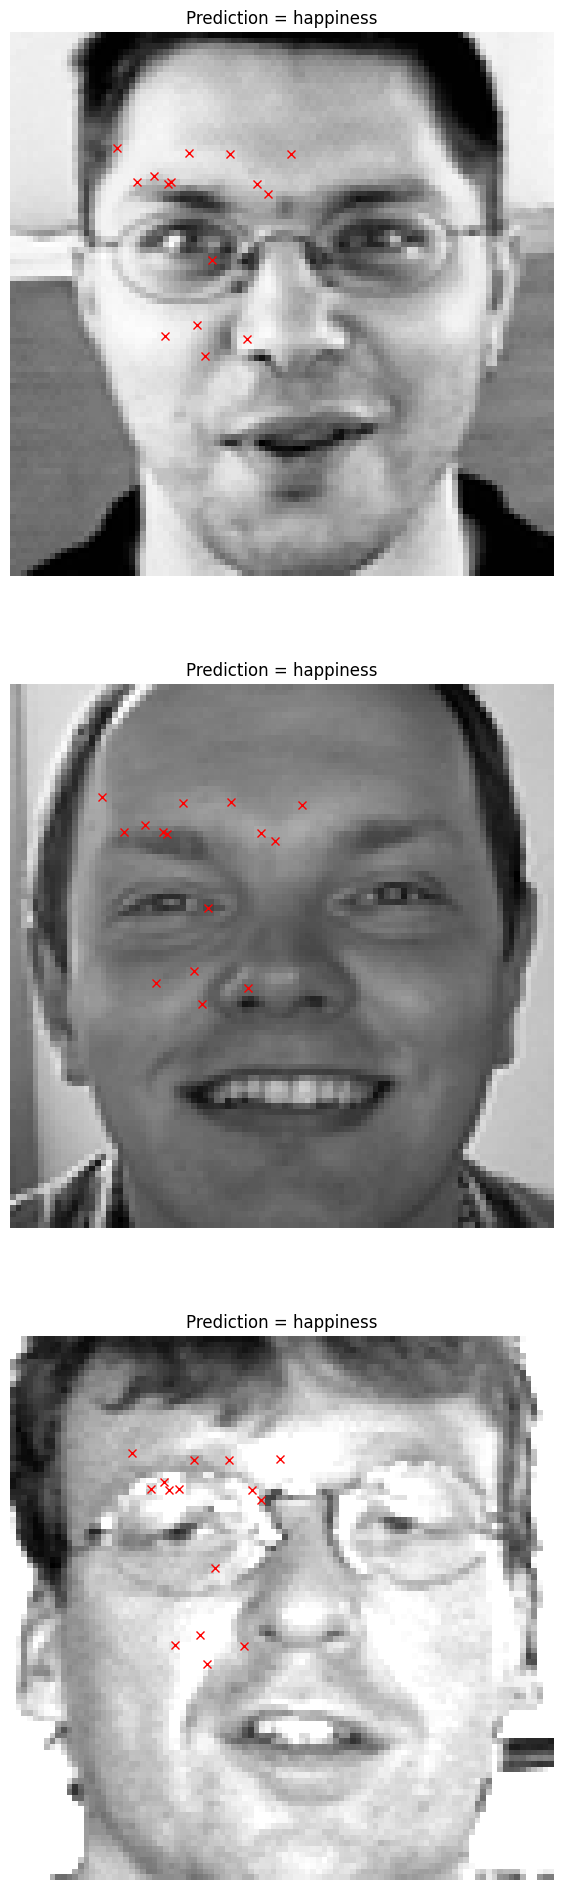

In [106]:
# Plotting the test images and their predicted keypoints and emotions
fig, axes = plt.subplots(3, 1, figsize = (24, 24))
axes = axes.ravel()

for i in range(3):

    axes[i].imshow(X_test[i].squeeze(),cmap='gray')
    axes[i].set_title('Prediction = {}'.format(label_to_text[df_predict['emotion'][i]]))
    axes[i].axis('off')
    for j in range(1,31,2):
            axes[i].plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'rx')


In [107]:
!mkdir -p ~/.cache/huggingface/gradio/frpc
!wget -O ~/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3 \
https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
!chmod +x ~/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3

--2026-08-18 12:23:50--  https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
Resolving cdn-media.huggingface.co (cdn-media.huggingface.co)... 52.222.244.123, 52.222.244.48, 52.222.244.21, ...
Connecting to cdn-media.huggingface.co (cdn-media.huggingface.co)|52.222.244.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11907224 (11M) [binary/octet-stream]
Saving to: ‘/root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3’

/root/.cache/huggin 100%[===================>]  11.36M  --.-KB/s    in 0.09s   

2026-08-18 12:23:50 (126 MB/s) - ‘/root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3’ saved [11907224/11907224]



In [112]:
!ps aux | grep tensorflow_model_server

root       37295  0.0  0.0   7376  3516 ?        S    12:25   0:00 /bin/bash -c ps aux | grep tensorflow_model_server
root       37297  0.0  0.0   6620  2392 ?        S    12:25   0:00 grep tensorflow_model_server


In [120]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4500 \
  --model_name=facial_keypoints \
  --model_base_path="/facial_keypoints_model" \
  >keypoint_server.log 2>&1

In [121]:
%%bash --bg

nohup tensorflow_model_server \
  --rest_api_port=4000 \
  --model_name=emotion_model \
  --model_base_path="/emotion_model" \
  >emotion_server.log 2>&1

In [122]:
!ps aux | grep tensorflow_model_server

root       41699  140  2.6 1882592 358528 ?      Sl   12:29   0:01 tensorflow_model_server --rest_api_port=4500 --model_name=facial_keypoints --model_base_path=/facial_keypoints_model
root       42489 76.0  1.4 1677656 196852 ?      Sl   12:29   0:00 tensorflow_model_server --rest_api_port=4000 --model_name=emotion_model --model_base_path=/emotion_model
root       44062  0.0  0.0   7376  3476 ?        S    12:29   0:00 /bin/bash -c ps aux | grep tensorflow_model_server
root       44064  0.0  0.0   6620  2496 ?        S    12:29   0:00 grep tensorflow_model_server


In [123]:
import json
import requests
import numpy as np
import cv2
import gradio as gr


# TensorFlow Serving endpoints
KEYPOINT_URL = (
    "http://localhost:4500/v1/models/"
    "facial_keypoints/versions/1:predict"
)

EMOTION_URL = (
    "http://localhost:4000/v1/models/"
    "emotion_model/versions/1:predict"
)


# Emotion classes
EMOTIONS = [
    "anger",
    "disgust",
    "sad",
    "happiness",
    "surprise"
]


def predict_from_image(image):

    if image is None:
        return None, "Please upload an image.", None

    try:

        # -----------------------------
        # 1. Preprocess image
        # -----------------------------

        # RGB → Grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Resize to model input size
        resized = cv2.resize(
            gray,
            (96, 96),
            interpolation=cv2.INTER_CUBIC
        ).astype(np.float32)

        # Add batch and channel dimensions
        # (96, 96) → (1, 96, 96, 1)
        X = resized.reshape(1, 96, 96, 1)


        # -----------------------------
        # 2. Prepare JSON
        # -----------------------------

        data = json.dumps({
            "signature_name": "serving_default",
            "instances": X.tolist()
        })

        headers = {
            "content-type": "application/json"
        }


        # -----------------------------
        # 3. Facial Keypoints Model
        # -----------------------------

        keypoint_response = requests.post(
            KEYPOINT_URL,
            data=data,
            headers=headers,
            timeout=30
        )

        keypoint_response.raise_for_status()

        keypoints = np.array(
            keypoint_response.json()["predictions"][0],
            dtype=np.float32
        )


        # -----------------------------
        # 4. Emotion Model
        # -----------------------------

        emotion_response = requests.post(
            EMOTION_URL,
            data=data,
            headers=headers,
            timeout=30
        )

        emotion_response.raise_for_status()

        emotion_probs = np.array(
            emotion_response.json()["predictions"][0],
            dtype=np.float32
        )


        # -----------------------------
        # 5. Get predicted emotion
        # -----------------------------

        predicted_class = int(
            np.argmax(emotion_probs)
        )

        predicted_emotion = EMOTIONS[predicted_class]

        confidence = float(
            emotion_probs[predicted_class]
        )


        # -----------------------------
        # 6. Draw facial keypoints
        # -----------------------------

        output_image = cv2.cvtColor(
            resized.astype(np.uint8),
            cv2.COLOR_GRAY2RGB
        )

        points = keypoints.reshape(-1, 2)

        for x, y in points:

            cv2.circle(
                output_image,
                (int(round(x)), int(round(y))),
                2,
                (255, 255, 255),
                -1
            )


        # -----------------------------
        # 7. Prediction result
        # -----------------------------

        result = (
            f"### Emotion: **{predicted_emotion.title()}**\n"
            f"### Confidence: **{confidence:.2%}**"
        )


        # Emotion probabilities
        probabilities = {
            EMOTIONS[i].title(): float(emotion_probs[i])
            for i in range(len(EMOTIONS))
        }


        return output_image, result, probabilities


    except Exception as e:

        return (
            None,
            f"### Error\n`{str(e)}`",
            None
        )


# =====================================
# Create Gradio Interface
# =====================================

demo = gr.Interface(

    fn=predict_from_image,

    inputs=gr.Image(
        type="numpy",
        label="Upload Face Image"
    ),

    outputs=[
        gr.Image(
            label="Facial Keypoints"
        ),

        gr.Markdown(
            label="Prediction"
        ),

        gr.Label(
            label="Emotion Probabilities",
            num_top_classes=5
        )
    ],

    title="Emotion AI",
    description=(
        "Upload a face image to detect facial keypoints "
        "and predict the person's emotion."
    )
)


# =====================================
# Launch
# =====================================

demo.launch(
    share=True,
    server_name="0.0.0.0"
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://18615b824f15637f2e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
